# Applying ComBat on simulated data:

Combat assumes data is of the form:

$y_{i,j} = \alpha_0 + X_i\beta_j + \gamma_{b(i)j} + \delta_{b(i)j}\epsilon_{ij}$

Where:

- $y_{i,j} $ is the derived features (i.e. the volume of the hippocampus)
- $\alpha_0 $ is the mean of the given feature
- $ X_i$ is a design matrix of covariates
- $\beta_j$ are the estimated covariate effects (usually from taking the psuedoinverse of the design with the dataset)
- $\gamma_{b(i)j} $ is the additive (location) effect
- $\delta_{b(i)j}$ is the multiplicative (scaling) effect
- $\epsilon_{ij}$ is the subject specific term, assumed to capture subject specific effects not described by covariates as well as measurement noise


Here, we will simulate some data as we did in section 1 and apply ComBat to it in order to see how it works and how well it does.

Try playing around with each of the batch (sites) characteristics to see how confounding between age, sex or other variables may effect harmonisation ad estimation of the batch effect.

In [ ]:
from block03_utils.SimulateDataBlock3 import make_simulator_input_gui
import matplotlib.pyplot as plt 
_ = make_simulator_input_gui()

After clicking done, you are left with the following variables:

- data -> $y_{ij}$
- covariates -> $X_i$, the subjects $\times$ covariate matrix
- betas -> $\beta_{j}$, the true covariate effects
- add_mean -> $\gamma_{jb(i)}$, the mean additive effect on the data from a given batch 
- multi_mean -> $\delta_{jb(i)}$, the mean multiplicative effect on the data from a given batch
- noise -> $\epsilon_{ij}$, the subject specific measurement/noise term

Following the form of the ComBat equation, we then linerally combine these variables get the data.

ComBat requires at least two columns of data and a vectors containing the batch labels in order to run.
It is also advised to include any biologically relevant variables 

You might want to create two dataframes here with the same covariate effects but with and without a batch effect for easier comparisson

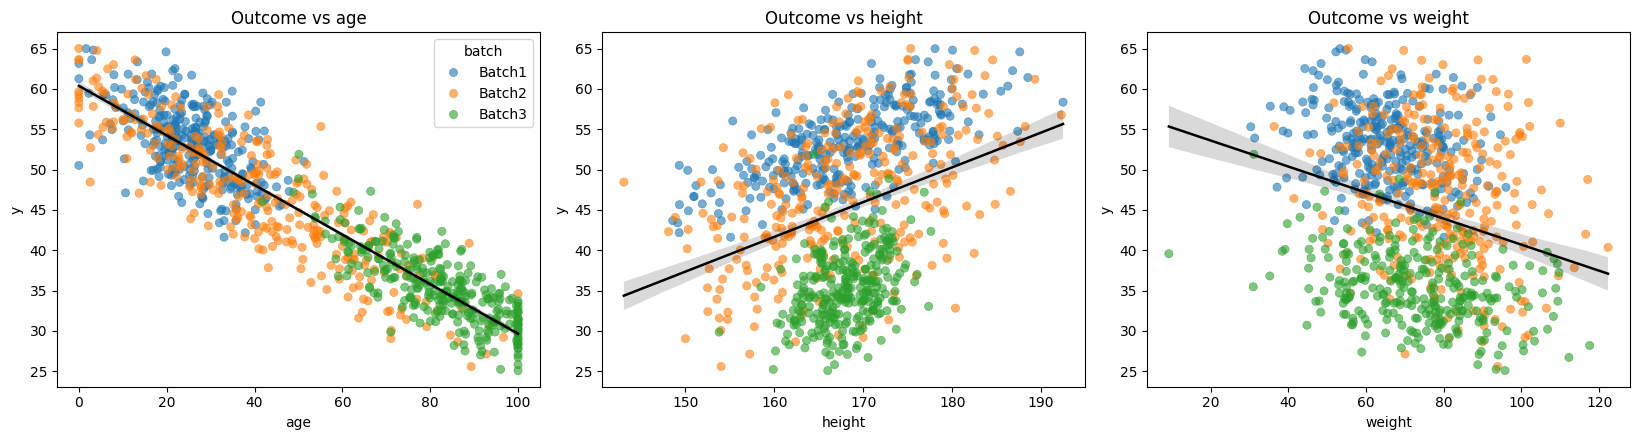

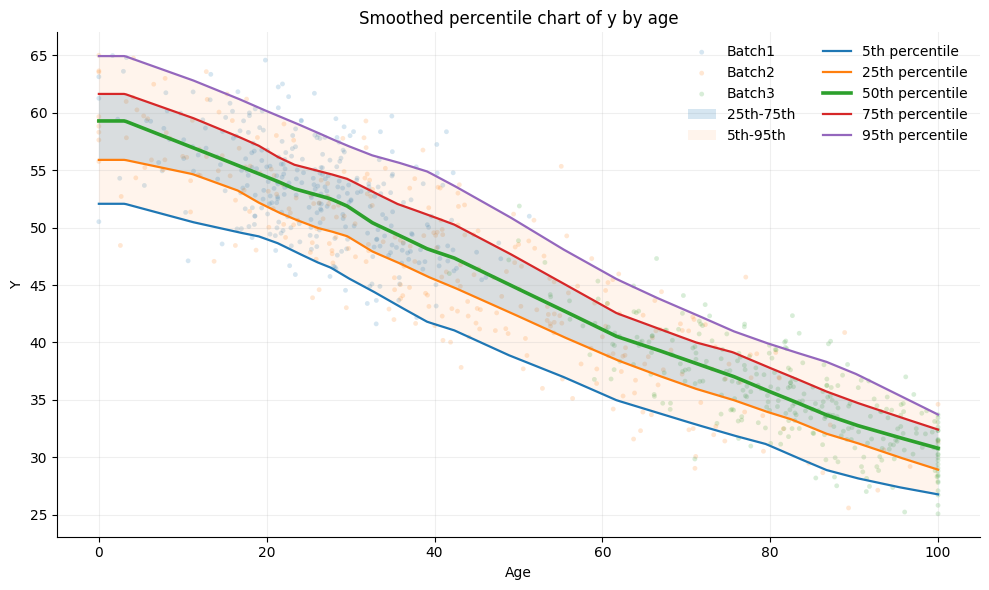

In [16]:
from block03_utils.SimulateDataBlock3 import simulate_batched_data
from block03_utils.PlottingBlock3 import plot_charts, plot_age_percentile_chart

# Store the data from the simulator as a dataframe 
data =[]
params = make_simulator_input_gui.last_result
data = params["data"]
batch = params["batch"]
covariate_specs = params["covariate_specs"]
betas = params["betas"]
batch_params = params["batch_params"]

df = simulate_batched_data(
    data=data,
    batch=batch,
    covariate_specs=covariate_specs,
    betas=betas,
    noise_sd=1.0,
    seed=123,
)

# You can also change the batch parameters here by removing the quotes and changing the values
fig = plot_charts(df, ["age", "height", "weight"], batch_col="batch", outcome_col="y")

# Also show the age nomogram:

fig, ax = plot_age_percentile_chart(
    df,
    age_col="age",
    value_col="y",
    batch_col="batch",
    n_bins=25,
    smooth_frac=0.25,
    show_points=True,
    show_batch_coloring=True,
)

plt.show()

In [17]:
# If you have defined a batch effect using the simulator, you can skip this block

batch_params = {
    "Batch1": {"add_mean": 0.00, "add_sd": 0.05, "multi_mean": 1.00, "multi_shape": 25.0},
    "Batch2": {"add_mean": 5, "add_sd": 0.08, "multi_mean": 1.5, "multi_shape": 18.0},
    "Batch3": {"add_mean": -6, "add_sd": 0.06, "multi_mean": 0.8, "multi_shape": 30.0},
}


### Now we will apply ComBat to the data:

Several versions of ComBat are available freely online in Python, R and MATLAB.

The original version can be found here [https://github.com/Jfortin1/ComBatHarmonization] and any publication of work using ComBat should always cite the original implementations for neuroscientific applications, but also the first implemntation which was introduced by Johnson et al., in the field of genomics.

The version we will be using today is adapted directly from this original code.

Some other available versions are as part of the neuroHarmonize Python package [https://github.com/rpomponio/neuroHarmonize]

As part of the DiagnoseHarmonise package [https://pypi.org/project/DiagnoseHarmonisation/]

And as part of the uniharmony package [https://pypi.org/project/uniharmony/]

Or as standalone implementations such as the version by Chen et al., which included harmonisation of covariates using principle component analysis (PCA) [https://github.com/andy1764/CovBat_Harmonization]

For this practical, we will be using a modified version from the DiagnoseHarmonisation package as it returns by defaults the estimated betas and the correction terms for each batch so that we can compare them with the true simulated values.

This version has been installed locally in the block03_utils:



In [23]:
# Load the module

from block03_utils.B03_ComBat import combat
from block03_utils.SimulateDataBlock3 import simulate_batched_data2
import numpy as np
# ComBat needs more than one column in order to run so we will create some additional columns that are just random noise for the purpose of demonstrating ComBat. 
# In a real dataset you would have multiple features that you want to harmonise, but for this example we will just create some random noise columns.


sim = simulate_batched_data2(
    data=data,
    batch=batch,
    n_cols=10,
    covariate_specs=covariate_specs,
    betas=betas,
    batch_params=batch_params,
    seed=123,
)


df = sim["df"]
y = sim["y"]          # shape (n, 3)
# Print shape and make sure that data and harmonised data match:
data = np.asarray(y, dtype=float)
data = np.asarray(data, dtype=float)

print(data.shape)   # quick check
print(data.ndim)    # 1 for vector, 2 for matrix

covariate_names = ["age", "sex", "height", "weight"]
X = sim["df"][covariate_names].to_numpy()
print(X)
print(X.shape)

(900, 10)
2
[[ 15.1087865    1.         174.85075733  67.23574406]
 [ 21.32213349   1.         165.32265572  70.19857413]
 [ 37.87925261   1.         149.30053152  62.69556106]
 ...
 [ 93.68757171   0.         167.65047171  72.37865308]
 [ 72.66636748   0.         170.53891688  70.25089182]
 [ 63.48997195   0.         167.95502322  44.3826329 ]]
(900, 4)


In [28]:
# Run the ComBat harmonisation on the data, this version of ComBat takes numpy arrays as the the input so we need to convert the dataframes to numpy arrays first. We also need to specify the batch column and the covariates that we want to include in the model.

ReturnPriors = True # whether to return the priors or not, if True then the output will be a dictionary with the harmonised data and the priors, if False then the output will just be the harmonised data.
combat_data = combat(
    data=data, # array of data to be harmonised, shape (n_samples, n_features)
    batch=batch, # array of batch labels, shape (n_samples,)
    mod=X, # array of covariates to include in the model, shape (n_samples, n_covariates)
    parametric=True, # whether to use parametric or non-parametric adjustments (we do not offer non-parametric and generally do not advise it)
    return_priors=ReturnPriors,
)

def print_inventory(dct):
    print("Items held:")
    for item, amount in dct.items():  # dct.iteritems() in Python 2
        print("{} ({})".format(item, amount))

# Print the size of the original data and the combat data to show that they are the same shape

# "Return priors must be either True or False"
if ReturnPriors:
    print("Original data shape:", data.shape)
    bayesdata = combat_data["bayesdata"]
else:
    print("Original data shape:", data.shape)
    print("ComBat data shape:", combat_data.shape)
    bayesdata = combat_data



Reference batch not given, defaulting to no reference
Empirical Bayes set to true
[combat] Found 3 batches
[combat] Adjusting for 4 covariate(s) of covariate level(s)
[combat] Standardizing Data across features
[combat] Fitting L/S model and finding priors
Size of gamma hat: (3, 10)
Size of delta hat: (3, 10)
[combat] Finding parametric adjustments
Size of gamma_star: (3, 10)
Original data shape: (900, 10)


## Compare the age nomograms and some other data characteristics before and after harmonisation:


We can compare the data before and after running ComBat.

We will do this three ways:

- Looking at batch histograms
- Looking at principle component clusters
- Examining the mean difference between batches
- Examining the variance difference between batches


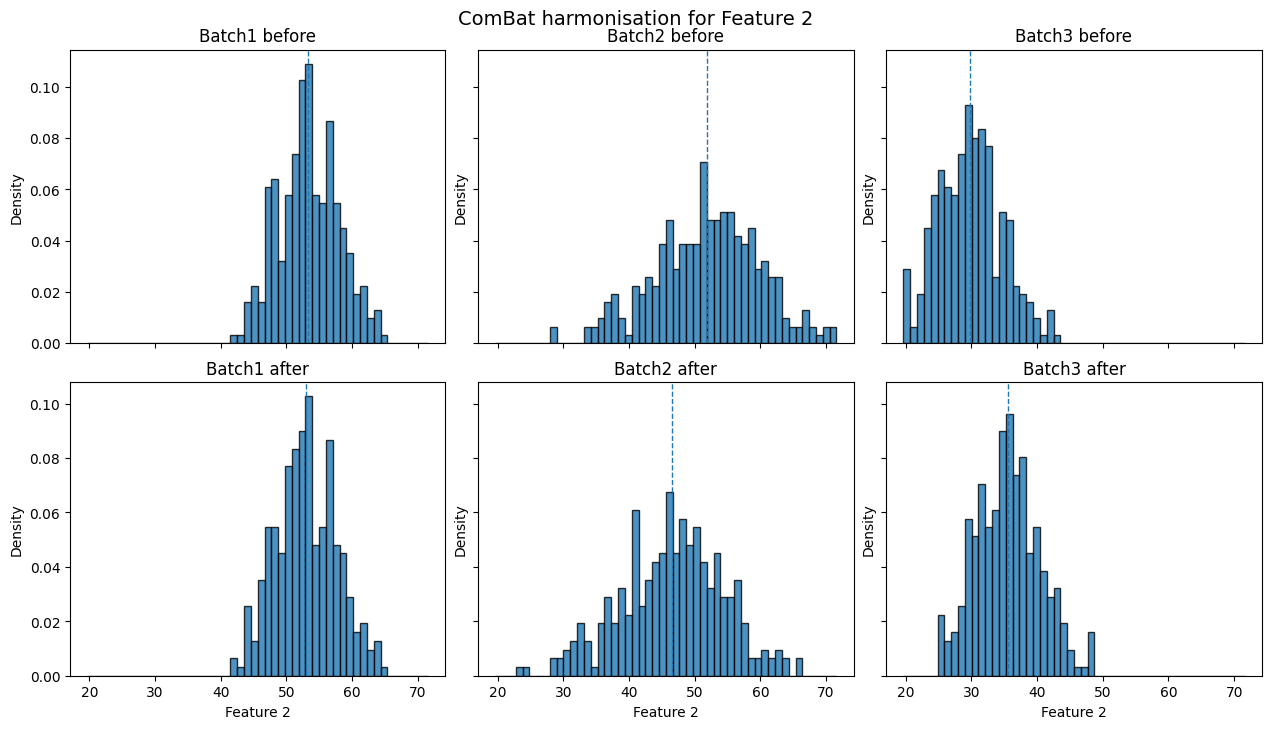

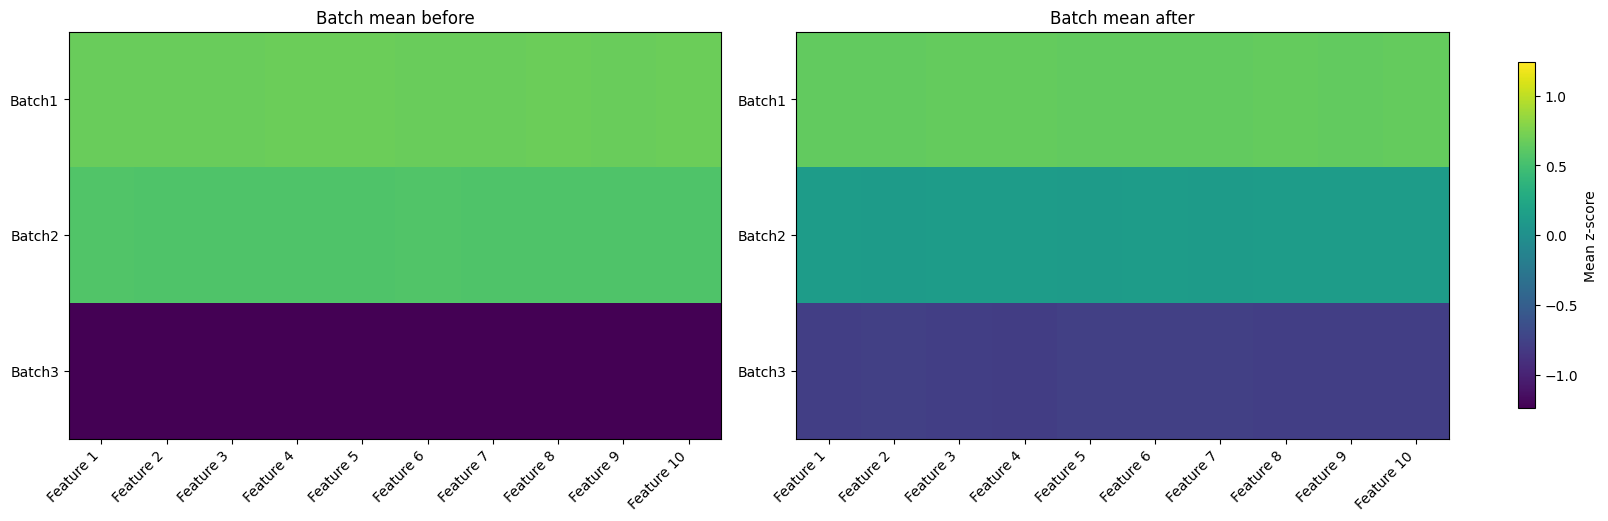

In [29]:
# Batch histograms:
from block03_utils.PlottingBlock3 import plot_combat_before_after

plot_combat_before_after(
    y_before=data,
    y_after=bayesdata,
    batch=batch,
    feature_names=None,
    feature_idx=1,   # change this to the feature you care about
    bins=50,
)


## Other visualisations:

We can look at other metrics to assess harmonisation accuracy, for example clustering when projecting the data using principal component analysis:

Here, distinct batch clusters by batch can be a sign of residual batch effects.


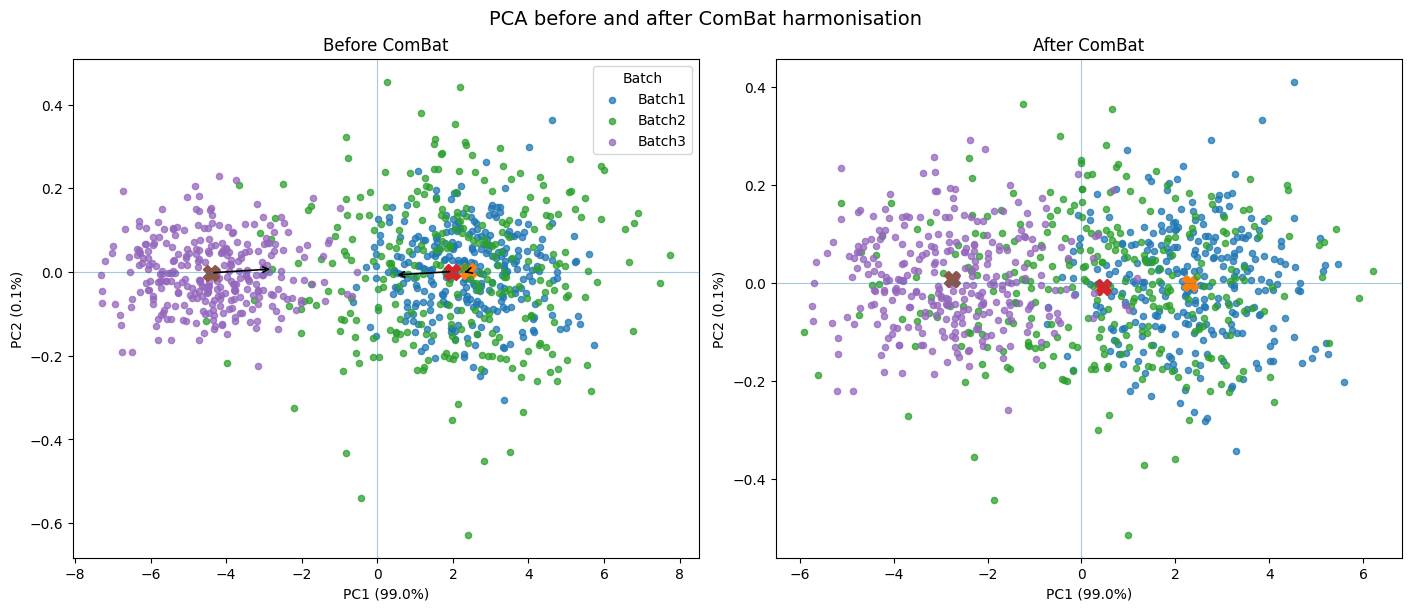

In [10]:
from block03_utils.PlottingBlock3 import plot_pca_before_after
result = plot_pca_before_after(
    y_before=data,
    y_after=bayesdata,
    batch=batch,
    feature_names=None,
    standardize=True,
    show_arrows=True,
)

plt.show()

Notice that there may still be distinct batch clusters before and after applying ComBat. However, this doesn't necessarily mean there is still residual batch effect.

Try making the covariate distributions more similar between batches and see if this clustering remains. Another approach is to use regression to remove these effects. This can be done internally within the ComBat implementation we provide as seen here:

    combat_data = combat(
        data=data, 
        batch=batch, 
        mod=X, 
        parametric=True, 
        return_priors=ReturnPriors,
        RegressCovariates=True,

    )


As an extension, have a look at the other data contained in the ComBat output when return priors is set to true.
This dataframe will then contain all of the parameters that were used in the estimation of the final ComBat corrections. You can also compare them directly with the 'true' values from simulation to see how close they are.

The solution for this can be found in block 3's solution tab. Have a think about what you see. Why might this differ a bit from what you expect?